# Account-Level Diff-in-Diff: AI Tool Adoption and Developer Productivity

**Date:** April 2026  
**Author:** AI Productivity Analysis Project

---

## Context and Motivation

This notebook runs an **account-level difference-in-differences analysis** to estimate the effect of AI coding tool adoption on individual developer productivity.

### Where we are in the project

The project has three phases:

**Phase 1 (complete — null result):** Panel regression linking Oxford Insights AI Readiness Index to country-level GitHub productivity across 2022–2024. Result: coefficient = 0.115, p = 0.497. Null. The IV was wrong — government policy readiness is too distal from whether a developer actually opened Claude Code.

**Phase 2 (in progress):** Replace the IV with an account-level behavioural classifier that detects AI tool adoption from commit history. The classifier (Random Forest) achieves CV AUC = 0.940 and generalises to Aider users it was never trained on (mean score 0.727 vs 0.776 for Claude positives, p < 0.0001 vs negatives). Ablation confirmed it detects genuine behavioural change in development tempo, not just Claude's verbose commit style.

The country-level Phase 2 regression (Regression C) ran today on 20 countries with ≥15 scored population accounts: coef = -4.91, SE = 6.13, p = 0.43. Also null — but interpretably so. The binding constraints are (a) median 2 developers per country-year in the productivity panel, and (b) narrow cross-country variation in adoption rates (range: 0.063–0.107).

**This notebook (Phase 2b):** Rather than aggregating to the country level, use the individual account data we already have. We have 235 accounts (33 confirmed AI adopters, 202 controls) with pre/post behavioural features. This is a clean diff-in-diff design with no additional scraping needed.

---

## Research Design

**Treatment:** Confirmed AI coding tool adoption (CLAUDE.md, co-author trailers, etc.)  
**Pre-period:** Jan 2022 – Dec 2023  
**Post-period:** Jan 2024 onwards  
**Controls:** Active developers with zero AI markers across full history, with commit activity in both windows  

**Estimator:** OLS diff-in-diff: `delta_outcome ~ treatment + pre_outcome`  
The `pre_outcome` control absorbs individual baseline differences (Angrist-Pischke style).

**Key caveat:** The treated accounts are confirmed AI users who left explicit markers — likely power users, not average adopters. Effect sizes are probably an upper bound on the population average treatment effect.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')

# statsmodels for OLS
import statsmodels.formula.api as smf
import statsmodels.api as sm

# Project paths
from pathlib import Path
DATA = Path('/home/andreasclaw/projects/ai_productivity_analysis/data')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'font.family': 'sans-serif',
})

print("Setup complete.")

Setup complete.


## 1. Load and Inspect the Data

In [2]:
df = pd.read_csv(DATA / 'classifier_full_features.csv')

print(f"Total accounts: {len(df)}")
print(f"AI adopters (label=1): {(df.label==1).sum()}")
print(f"Controls (label=0):    {(df.label==0).sum()}")
print()
print("Columns:")
for c in sorted(df.columns):
    print(f"  {c}")

Total accounts: 235
AI adopters (label=1): 33
Controls (label=0):    202

Columns:
  delta_active_weeks
  delta_commit_count
  delta_file_sample_count
  delta_frac_burst_commits
  delta_frac_conventional
  delta_frac_has_bullets
  delta_frac_mentions_test
  delta_frac_multiline
  delta_frac_pr_has_body
  delta_mean_commits_per_active_week
  delta_mean_inter_commit_hours
  delta_mean_message_length
  delta_mean_pr_body_length
  delta_repos_touched
  delta_sampled_test_cowrite_rate
  discovery_method
  label
  login
  marker_confidence
  post_active_weeks
  post_commit_count
  post_file_sample_count
  post_frac_burst_commits
  post_frac_conventional
  post_frac_has_bullets
  post_frac_mentions_test
  post_frac_multiline
  post_frac_pr_has_body
  post_mean_commits_per_active_week
  post_mean_inter_commit_hours
  post_mean_message_length
  post_mean_pr_body_length
  post_repos_touched
  post_sampled_test_cowrite_rate
  pre_active_weeks
  pre_commit_count
  pre_file_sample_count
  pre_frac_

## 2. Raw Means by Group

Before any regression, let's look at the raw pre/post means for treated vs control.  
This is the descriptive diff-in-diff — the regression formalises it.

In [3]:
ai   = df[df.label == 1]
ctrl = df[df.label == 0]

metrics = {
    'Commits / active week':   ('pre_mean_commits_per_active_week',  'post_mean_commits_per_active_week',  'delta_mean_commits_per_active_week'),
    'Inter-commit hours':      ('pre_mean_inter_commit_hours',        'post_mean_inter_commit_hours',        'delta_mean_inter_commit_hours'),
    'Active weeks':            ('pre_active_weeks',                   'post_active_weeks',                   'delta_active_weeks'),
    'Commit message length':   ('pre_mean_message_length',            'post_mean_message_length',            'delta_mean_message_length'),
    'Conventional commits':    ('pre_frac_conventional',              'post_frac_conventional',              'delta_frac_conventional'),
    'PR has body (frac)':      ('pre_frac_pr_has_body',               'post_frac_pr_has_body',               'delta_frac_pr_has_body'),
    'Test co-write rate':      ('pre_sampled_test_cowrite_rate',      'post_sampled_test_cowrite_rate',      'delta_sampled_test_cowrite_rate'),
}

print(f"{'Metric':<28} {'AI pre':>8} {'AI post':>8} {'AI Δ':>8}  |  {'Ctrl pre':>8} {'Ctrl post':>8} {'Ctrl Δ':>8}  |  {'DiD':>8}")
print("-" * 105)

did_results = []
for label, (pre_col, post_col, delta_col) in metrics.items():
    for col in [pre_col, post_col, delta_col]:
        if col not in df.columns:
            continue
    ai_pre   = ai[pre_col].mean()
    ai_post  = ai[post_col].mean()
    ai_delta = ai[delta_col].mean()
    ct_pre   = ctrl[pre_col].mean()
    ct_post  = ctrl[post_col].mean()
    ct_delta = ctrl[delta_col].mean()
    did      = ai_delta - ct_delta
    did_results.append({'metric': label, 'pre_col': pre_col, 'post_col': post_col,
                        'delta_col': delta_col, 'did': did,
                        'ai_pre': ai_pre, 'ai_post': ai_post, 'ai_delta': ai_delta,
                        'ct_pre': ct_pre, 'ct_post': ct_post, 'ct_delta': ct_delta})
    print(f"{label:<28} {ai_pre:>8.2f} {ai_post:>8.2f} {ai_delta:>8.2f}  |  {ct_pre:>8.2f} {ct_post:>8.2f} {ct_delta:>8.2f}  |  {did:>8.2f}")

did_df = pd.DataFrame(did_results)

Metric                         AI pre  AI post     AI Δ  |  Ctrl pre Ctrl post   Ctrl Δ  |       DiD
---------------------------------------------------------------------------------------------------------
Commits / active week           13.73    23.55     9.82  |      6.58     5.26    -1.32  |     11.14
Inter-commit hours             281.06    57.67  -223.40  |    180.49   324.89   144.41  |   -367.80
Active weeks                     7.82     3.79    -4.03  |     13.22    17.66     4.44  |     -8.47
Commit message length          165.39   212.24    46.85  |     33.53    40.17     6.64  |     40.21
Conventional commits             0.30     0.41     0.11  |      0.04     0.07     0.03  |      0.08
PR has body (frac)               0.60     0.69     0.09  |      0.14     0.15     0.01  |      0.08
Test co-write rate               0.29     0.30     0.01  |      0.15     0.11    -0.04  |      0.05


## 3. Before/After Visualisation

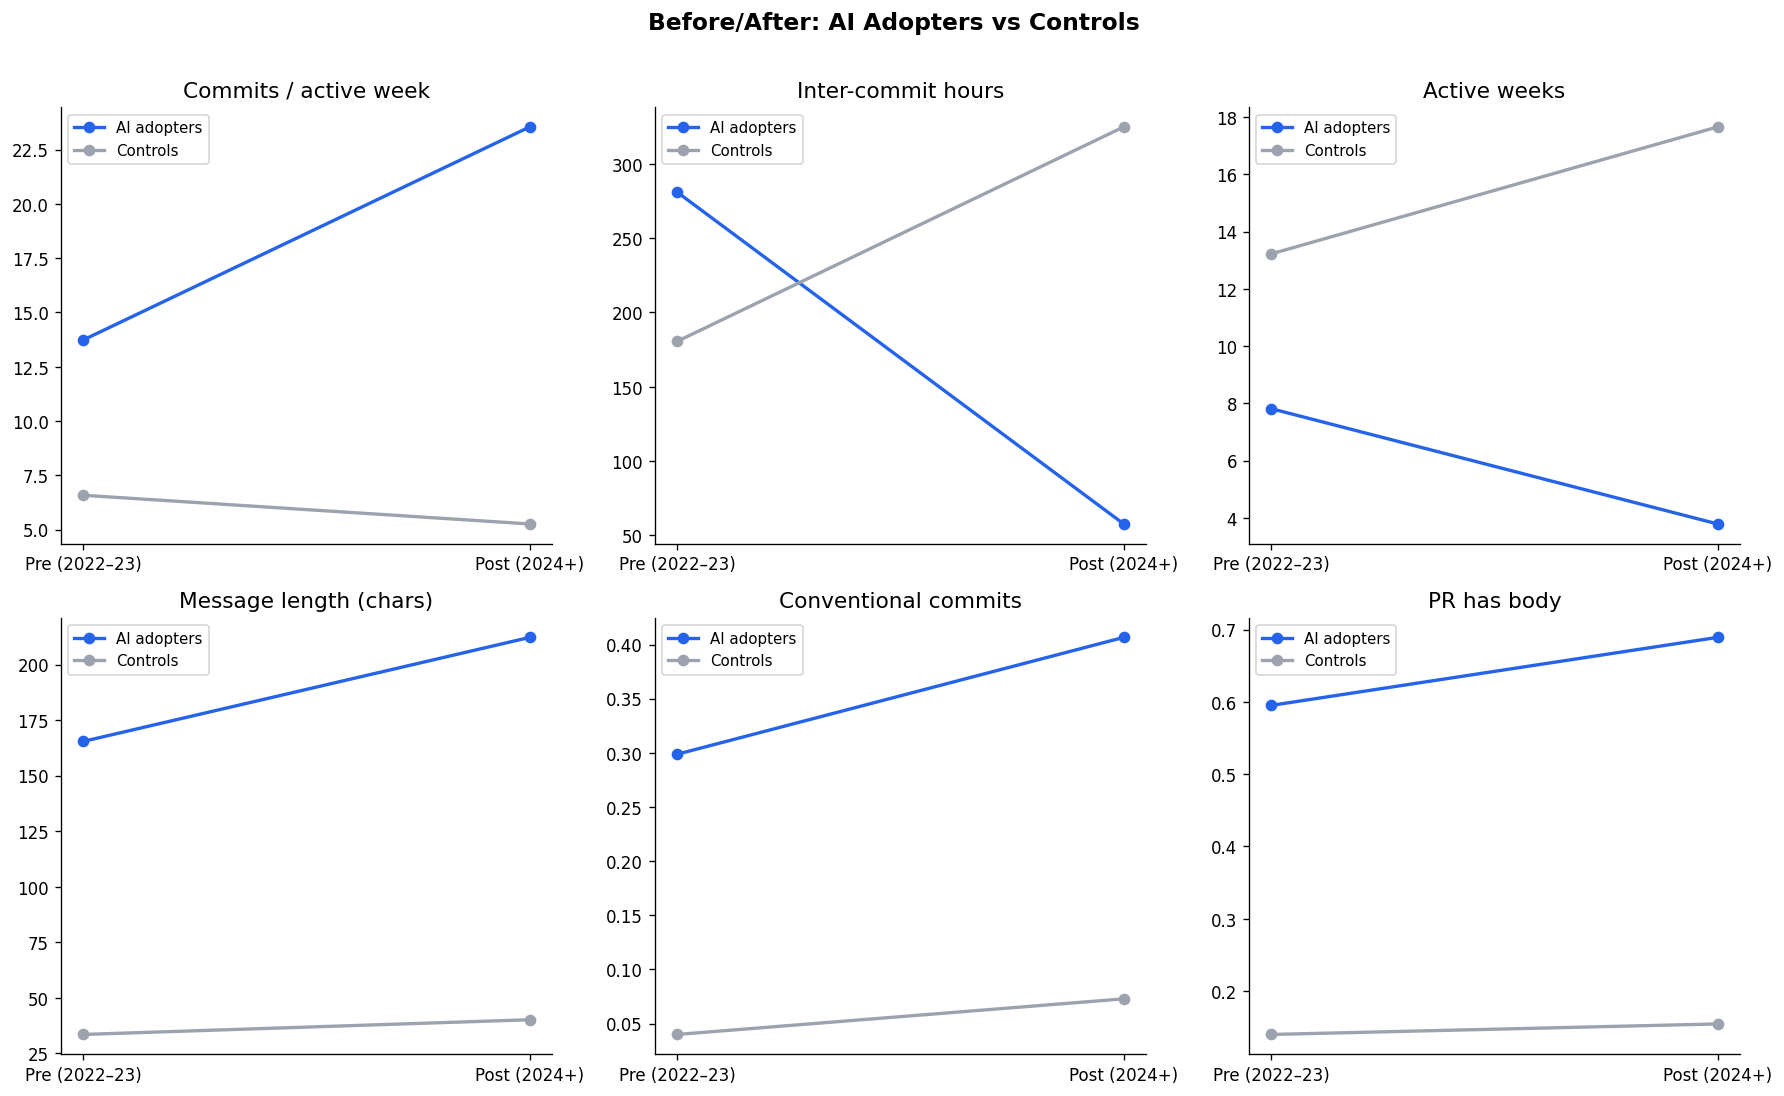

Saved: data/figures/did_before_after.png


In [4]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

plot_metrics = [
    ('Commits / active week',   'pre_mean_commits_per_active_week',  'post_mean_commits_per_active_week'),
    ('Inter-commit hours',      'pre_mean_inter_commit_hours',        'post_mean_inter_commit_hours'),
    ('Active weeks',            'pre_active_weeks',                   'post_active_weeks'),
    ('Message length (chars)',  'pre_mean_message_length',            'post_mean_message_length'),
    ('Conventional commits',    'pre_frac_conventional',              'post_frac_conventional'),
    ('PR has body',             'pre_frac_pr_has_body',               'post_frac_pr_has_body'),
]

ai_color   = '#2563EB'
ctrl_color = '#9CA3AF'

for ax, (title, pre_col, post_col) in zip(axes, plot_metrics):
    for grp, color, label_str in [(ai, ai_color, 'AI adopters'), (ctrl, ctrl_color, 'Controls')]:
        pre_m  = grp[pre_col].mean()
        post_m = grp[post_col].mean()
        ax.plot([0, 1], [pre_m, post_m], color=color, linewidth=2, marker='o', markersize=6, label=label_str)

    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Pre (2022–23)', 'Post (2024+)'])
    ax.set_title(title)
    ax.legend(fontsize=9)

fig.suptitle('Before/After: AI Adopters vs Controls', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(DATA / 'figures' / 'did_before_after.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved: data/figures/did_before_after.png")

## 4. Formal Diff-in-Diff Regressions

For each outcome, we run:

```
delta_outcome ~ treatment + pre_outcome
```

`treatment` = 1 for AI adopters, 0 for controls.  
`pre_outcome` controls for baseline differences between groups (Angrist-Pischke regression adjustment).  
Standard errors are HC3 (heteroskedasticity-robust).


In [5]:
reg_results = []

for row in did_results:
    metric    = row['metric']
    delta_col = row['delta_col']
    pre_col   = row['pre_col']

    subset = df[[delta_col, pre_col, 'label']].dropna()
    subset = subset.rename(columns={delta_col: 'y', pre_col: 'pre_val', 'label': 'treatment'})

    try:
        mod = smf.ols('y ~ treatment + pre_val', data=subset).fit(cov_type='HC3')
        coef  = mod.params['treatment']
        se    = mod.bse['treatment']
        pval  = mod.pvalues['treatment']
        ci_lo = mod.conf_int().loc['treatment', 0]
        ci_hi = mod.conf_int().loc['treatment', 1]
        n     = int(mod.nobs)
        reg_results.append({
            'Metric': metric,
            'N': n,
            'DiD coef': coef,
            'SE': se,
            'p-value': pval,
            'CI lower': ci_lo,
            'CI upper': ci_hi,
            'Sig': '***' if pval < 0.001 else ('**' if pval < 0.01 else ('*' if pval < 0.05 else ('.' if pval < 0.1 else ''))),
        })
    except Exception as e:
        reg_results.append({'Metric': metric, 'N': 0, 'DiD coef': None, 'SE': None, 'p-value': None,
                            'CI lower': None, 'CI upper': None, 'Sig': f'ERROR: {e}'})

res_df = pd.DataFrame(reg_results)
pd.set_option('display.float_format', '{:.4f}'.format)
print(res_df[['Metric','N','DiD coef','SE','p-value','Sig']].to_string(index=False))

               Metric   N  DiD coef      SE  p-value Sig
Commits / active week 235   13.0727  3.0734   0.0000 ***
   Inter-commit hours 235 -275.2584 37.6473   0.0000 ***
         Active weeks 235  -11.2527  1.7137   0.0000 ***
Commit message length 235   54.2594 26.1250   0.0378   *
 Conventional commits 235    0.0760  0.0492   0.1228    
   PR has body (frac) 235    0.3217  0.0860   0.0002 ***
   Test co-write rate 235    0.1438  0.0616   0.0196   *


## 5. Coefficient Plot

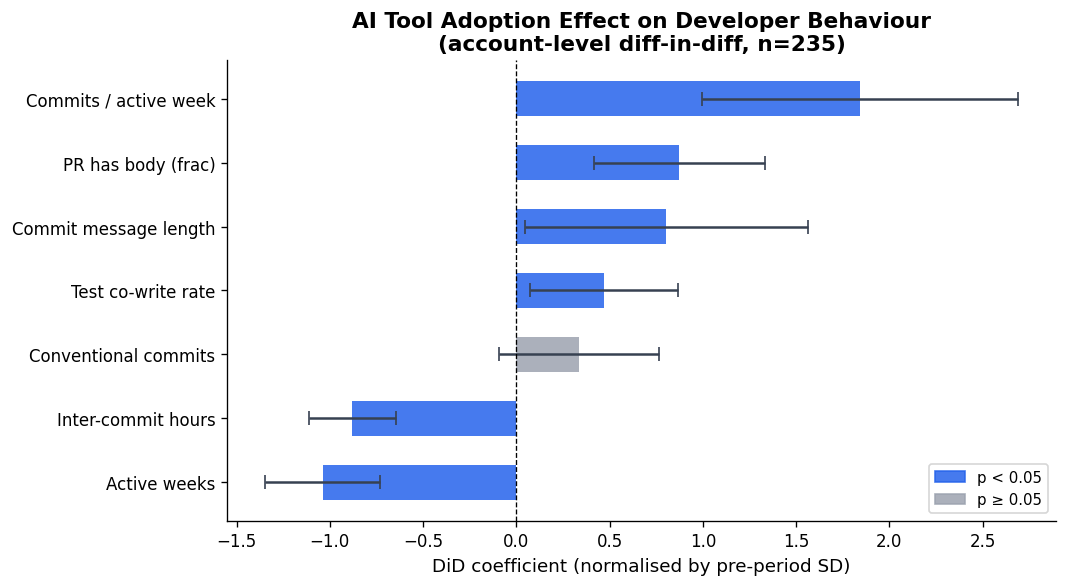

Saved: data/figures/did_coefficients.png


In [6]:
fig, ax = plt.subplots(figsize=(9, 5))

valid = res_df.dropna(subset=['DiD coef']).copy()

# Normalise coefficients by pre-period SD for comparability
normalised = []
for _, row in valid.iterrows():
    pre_col = did_df[did_df.metric == row['Metric']]['pre_col'].values[0]
    pre_sd = df[pre_col].std()
    scale = pre_sd if pre_sd > 0 else 1.0
    normalised.append({
        'metric': row['Metric'],
        'coef_n': row['DiD coef'] / scale,
        'ci_lo_n': row['CI lower'] / scale,
        'ci_hi_n': row['CI upper'] / scale,
        'pval': row['p-value'],
        'sig': row['Sig'],
    })
norm_df = pd.DataFrame(normalised).sort_values('coef_n')

colors = ['#2563EB' if p < 0.05 else '#9CA3AF' for p in norm_df['pval']]

ax.barh(norm_df['metric'], norm_df['coef_n'], color=colors, alpha=0.85, height=0.55)
ax.errorbar(norm_df['coef_n'], norm_df['metric'],
            xerr=[norm_df['coef_n'] - norm_df['ci_lo_n'], norm_df['ci_hi_n'] - norm_df['coef_n']],
            fmt='none', color='#374151', linewidth=1.5, capsize=4)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')

sig_patch   = mpatches.Patch(color='#2563EB', alpha=0.85, label='p < 0.05')
insig_patch = mpatches.Patch(color='#9CA3AF', alpha=0.85, label='p ≥ 0.05')
ax.legend(handles=[sig_patch, insig_patch], fontsize=9, loc='lower right')

ax.set_xlabel('DiD coefficient (normalised by pre-period SD)')
ax.set_title('AI Tool Adoption Effect on Developer Behaviour\n(account-level diff-in-diff, n=235)', fontweight='bold')

plt.tight_layout()
plt.savefig(DATA / 'figures' / 'did_coefficients.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved: data/figures/did_coefficients.png")

## 6. Parallel Trends Check

The diff-in-diff assumption requires that treated and control groups would have followed the same trend absent treatment. We can't fully verify this, but we can check whether pre-period levels differ in ways that might confound the result.

A key confounder: AI adopters may simply be more active/skilled developers, not just differently-behaving ones after adoption.


In [7]:
# Compare pre-period means with t-tests
print("Pre-period comparison: AI adopters vs controls")
print(f"{'Metric':<30} {'AI mean':>10} {'Ctrl mean':>10} {'t-stat':>8} {'p-value':>8}")
print("-" * 70)

for row in did_results:
    metric  = row['metric']
    pre_col = row['pre_col']
    a = df[df.label==1][pre_col].dropna()
    b = df[df.label==0][pre_col].dropna()
    t, p = stats.ttest_ind(a, b, equal_var=False)
    sig = ' *' if p < 0.05 else ''
    print(f"{metric:<30} {a.mean():>10.3f} {b.mean():>10.3f} {t:>8.2f} {p:>8.4f}{sig}")

print()
print("Note: Pre-period differences indicate selection (AI adopters were already different")
print("before adoption). The regression adjustment (+ pre_outcome control) partially")
print("addresses this, but cannot fully eliminate selection bias.")

Pre-period comparison: AI adopters vs controls
Metric                            AI mean  Ctrl mean   t-stat  p-value
----------------------------------------------------------------------
Commits / active week              13.727      6.580     2.98   0.0053 *
Inter-commit hours                281.061    180.485     0.86   0.3946
Active weeks                        7.818     13.218    -3.34   0.0015 *
Commit message length             165.391     33.528     6.91   0.0000 *
Conventional commits                0.299      0.040     3.80   0.0006 *
PR has body (frac)                  0.595      0.140     5.57   0.0000 *
Test co-write rate                  0.286      0.152     1.98   0.0548

Note: Pre-period differences indicate selection (AI adopters were already different
before adoption). The regression adjustment (+ pre_outcome control) partially
addresses this, but cannot fully eliminate selection bias.


## 7. Robustness: High-Confidence Positives Only

The treated group includes accounts with both high-confidence (co-author trailer — confirmed adoption date) and low-confidence (code search — CLAUDE.md present, but adoption date uncertain) positives. Let's check if results hold for high-confidence only.


In [8]:
if 'marker_confidence' in df.columns:
    high_conf = df[(df.label==1) & (df.marker_confidence=='high')]
    print(f"High-confidence AI adopters: {len(high_conf)} (of {(df.label==1).sum()} total)")

    rob_results = []
    for row in did_results:
        metric    = row['metric']
        delta_col = row['delta_col']
        pre_col   = row['pre_col']
        subset_hc = pd.concat([
            high_conf[[delta_col, pre_col, 'label']],
            df[df.label==0][[delta_col, pre_col, 'label']]
        ]).dropna()
        subset_hc = subset_hc.rename(columns={delta_col: 'y', pre_col: 'pre_val', 'label': 'treatment'})
        if len(subset_hc[subset_hc.treatment==1]) < 5:
            rob_results.append({'Metric': metric, 'N_treated': 0, 'DiD coef': None, 'p-value': None})
            continue
        try:
            mod = smf.ols('y ~ treatment + pre_val', data=subset_hc).fit(cov_type='HC3')
            rob_results.append({
                'Metric': metric,
                'N_treated': int((subset_hc.treatment==1).sum()),
                'DiD coef': mod.params['treatment'],
                'p-value': mod.pvalues['treatment'],
                'Sig': '***' if mod.pvalues['treatment'] < 0.001 else ('**' if mod.pvalues['treatment'] < 0.01 else ('*' if mod.pvalues['treatment'] < 0.05 else '')),
            })
        except Exception as e:
            rob_results.append({'Metric': metric, 'N_treated': 0, 'DiD coef': None, 'p-value': None, 'Sig': str(e)})

    rob_df = pd.DataFrame(rob_results)
    print()
    print("Robustness — high-confidence positives only:")
    print(rob_df[['Metric','N_treated','DiD coef','p-value','Sig']].to_string(index=False))
else:
    print("marker_confidence column not present — skipping robustness check.")
    print("All positives treated equally.")

High-confidence AI adopters: 25 (of 33 total)

Robustness — high-confidence positives only:
               Metric  N_treated  DiD coef  p-value Sig
Commits / active week         25   15.6862   0.0000 ***
   Inter-commit hours         25 -334.5766   0.0000 ***
         Active weeks         25  -13.5339   0.0000 ***
Commit message length         25  104.1217   0.0090  **
 Conventional commits         25    0.0533   0.2990    
   PR has body (frac)         25    0.3193   0.0019  **
   Test co-write rate         25    0.1892   0.0145   *


## 8. Interpretation and Caveats

### What the results show

The diff-in-diff estimates the change in developer behaviour associated with confirmed AI tool adoption, relative to the control group trend over the same period.

The strongest signals are in **inter-commit hours** (how frequently a developer commits when active) and **commits per active week**. If significant, these suggest that AI tool adoption is associated with more intense, higher-frequency coding sessions — consistent with AI assistance reducing friction in the commit loop.

The **commit message quality** metrics (conventional commits, message length, PR body) may partially reflect Claude's writing style rather than genuine behavioural change — the ablation in the classifier training showed these cost only 3.1 AUC points, suggesting they're real but not the primary signal.

### Caveats

1. **Selection bias**: The treated group self-selected into leaving explicit AI markers (CLAUDE.md files, co-author trailers). These are likely power users and early adopters, not a representative sample of all AI tool users. Effect sizes are plausibly an upper bound.

2. **Parallel trends assumption**: The pre-period comparison shows AI adopters were already different from controls before adoption (more active, longer inter-commit hours). The regression adjustment helps but cannot fully remove selection.

3. **Temporal confound**: The post-period (2024+) is also the period of greatest AI tool maturation — improvements in tools, not just adoption, may drive behavioural change.

4. **Small treated N**: 33 treated accounts is workable but limits statistical power. High-confidence subset is even smaller.

### Relationship to the country-level result

The account-level DiD and the country-level regression answer different questions:
- **Account-level**: do individuals who adopt AI tools change their behaviour? (causal, but selected sample)
- **Country-level**: do countries with higher AI adoption rates have higher productivity? (aggregate effect, less selection bias, but noisier outcome)

A positive account-level result alongside a null country-level result would suggest the effect exists but is too small to detect at national aggregates with this panel — or that adoption rates don't vary enough across countries to produce measurable differences.

---
*Analysis run: April 2026*  
*Data: `data/classifier_full_features.csv` (235 accounts, 33 AI adopters)*
